# Basic Importing and Inspection

In [53]:
%pip install lightgbm
%pip install catboost


Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/100.2 MB 7.4 MB/s eta 0:00:14
   - -------------------------------------- 2.9/100.2 MB 8.1 MB/s eta 0:00:13
   - -------------------------------------- 3.9/100.2 MB 8.1 MB/s eta 0:00:12
   -- ------------------------------------- 5.8/100.2 MB 7.3 MB/s eta 0:00:13
   -- ------------------------------------- 7.1/100.2 MB 7.1 MB/s eta 0:00:14
   --- ------------------------------------ 7.9/100.2 MB 6.6 MB/s eta 0:00:14
   --- ------------------------------------ 8.7/100.2 MB 6.1 MB/s eta 0:00:15
   --- ------------------------------------ 9.4/100.2 MB 5.9 MB/s eta 0:00:16
   ---- ----------------------------------- 10.2/100.2 MB 5.6 MB/s eta 0:00:16
   ---- ----------------------------------- 11.3/100.2 MB 5.6 MB/s eta 0:00:16
   ---- ----------------------------------- 12.3/100.2 MB 5.5 MB/s eta 0:00:16
  

In [ ]:
# Importing Basic Libraries
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# Importing Libraries for Modeling
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

# Importing Libraries for Models
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


In [40]:
# Importing Datasets
train = pd.read_csv('../data/train (1).csv')
test = pd.read_csv('../data/test.csv')

# Creating a copy to preserve orignial dataset
train_df = train.copy()
test_df = test.copy()

In [41]:
# Displaying Basic Information of the Dataset

def inspect_dataset(df, target_col=None):
    """
    Performs a clean, text-based inspection of a dataframe.
    Works perfectly in standard Python scripts, terminals, or standard notebooks.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset you want to inspect (e.g., train_df).
    target_col : str, optional
        The name of your target variable/label column.
    """
    # 1. Header and Basic Dimensions
    print("=" * 80)
    print("                        DATASET INSPECTION REPORT")
    print("=" * 80)
    print(f"SHAPE:")
    print(f"   • Rows:    {df.shape[0]}")
    print(f"   • Columns: {df.shape[1]:,}")
    
    # 2. Target Variable Analysis (If provided)
    print("\n" + "-" * 80)
    print("TARGET VARIABLE ANALYSIS")
    print("-" * 80)
    if target_col:
        if target_col in df.columns:
            print(f"Selected Target Column: '{target_col}'\n")
            # If the target is categorical/discrete
            if df[target_col].nunique() < 20:
                print("Type: Categorical/Discrete (Value Counts & Percentages):")
                counts = df[target_col].value_counts(dropna=False)
                pcts = df[target_col].value_counts(dropna=False, normalize=True) * 100
                target_summary = pd.DataFrame({'Count': counts, 'Percentage (%)': pcts.round(2)})
                print(target_summary)
            else:
                print("Type: Continuous/Numerical (Summary Statistics):")
                print(df[[target_col]].describe().T)
        else:
            print(f"[!] Warning: '{target_col}' was not found in the dataframe columns.")
    else:
        print("[ACTION REQUIRED]: No target variable specified.")
        print(" -> Pass target_col='your_column_name' to analyze your label.")

    # 3. Missing Values & Data Types Overview
    print("\n" + "-" * 80)
    print("COLUMNS, DATA TYPES, AND MISSING VALUES")
    print("-" * 80)
    
    inspect_df = pd.DataFrame({
        'Data Type': df.dtypes,
        'Unique Values': df.nunique(),
        'Missing Values': df.isnull().sum(),
        'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2)
    }).sort_values(by='Missing Values', ascending=False)
    
    print(inspect_df)

    # 4. Numerical Summary Statistics
    num_cols = df.select_dtypes(include=['number']).columns
    if len(num_cols) > 0:
        print("\n" + "-" * 80)
        print("NUMERICAL COLUMNS SUMMARY")
        print("-" * 80)
        print(df.describe().T.round(2))
        
    # 5. Categorical Summary Statistics
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        print("\n" + "-" * 80)
        print("CATEGORICAL COLUMNS SUMMARY")
        print("-" * 80)
        print(df.describe(include=['object', 'category']).T)

    # 6. Dataset Preview (Head)
    print("\n" + "-" * 80)
    print("DATASET PREVIEW (First 5 Rows)")
    print("-" * 80)
    print(df.head())
    print("=" * 80 + "\n")


inspect_dataset(train_df, target_col='Churn')


                        DATASET INSPECTION REPORT
SHAPE:
   • Rows:    594194
   • Columns: 21

--------------------------------------------------------------------------------
TARGET VARIABLE ANALYSIS
--------------------------------------------------------------------------------
Selected Target Column: 'Churn'

Type: Categorical/Discrete (Value Counts & Percentages):
        Count  Percentage (%)
Churn                        
No     460377           77.48
Yes    133817           22.52

--------------------------------------------------------------------------------
COLUMNS, DATA TYPES, AND MISSING VALUES
--------------------------------------------------------------------------------
                 Data Type  Unique Values  Missing Values  Missing (%)
id                   int64         594194               0          0.0
DeviceProtection    object              3               0          0.0
TotalCharges       float64          31910               0          0.0
MonthlyCharges     f

- 77.84% of people have 0 as their churn prediction. 
- Reduce False Positives 
- No missing values
- Industry: Telecommunications (providing phone and internet services)
- dtypes: float64(2), int64(3), object(16) (by info)

In [42]:
# Defining categorical and numerical columns for further analysis
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
binary_cols = ['SeniorCitizen']
target = ["Churn"]
cat_cols = train_df.columns.difference(num_cols + binary_cols + ['Churn'] + ["id"]).tolist()

# EDA

In [43]:
# # Visualizing Categorical Features with respect to Churn


# for i, col in enumerate(cat_cols):
#     plt.figure(figsize=(6, 4))
#     sns.countplot(data=train_df, x=col, hue='Churn', palette='viridis')
#     plt.title(f'Churn Distribution by {col}')

# plt.tight_layout()
# plt.show()

- **Contract**
    - `Month-to-month` customers churn the most.
    - `One year` and `Two year` contracts show much lower churn.

- **Dependents**
    - Customers without dependents churn more than those with dependents.

- **Payment Method**
    - `Electronic check` has the highest churn rate.

- **Internet Service**
    - `Fiber optic` has the highest churn.
    - `No internet service` has the lowest churn.

- **Device Protection**
    - Customers without device protection are more likely to churn.

- **Multiple Lines**
    - Customers with multiple lines show higher churn.

- **Online Backup**
    - Lack of online backup is associated with higher churn.

- **Online Security**
    - Customers without online security churn more.

- **Paperless Billing**
    - `PaperlessBilling` customers churn more than those with paper billing.

- **Partner**
    - Customers without a partner churn more than those with a partner.

- **Phone Service**
    - Churn is slightly higher for customers with phone service, but the difference is small.

- **Streaming Movies / TV**
    - Little difference in churn between yes/no.
    - Customers with `No internet service` generally do not churn.

- **Tech Support**
    - Customers without tech support churn a lot.

- **Gender**
    - Gender shows almost no difference in churn.

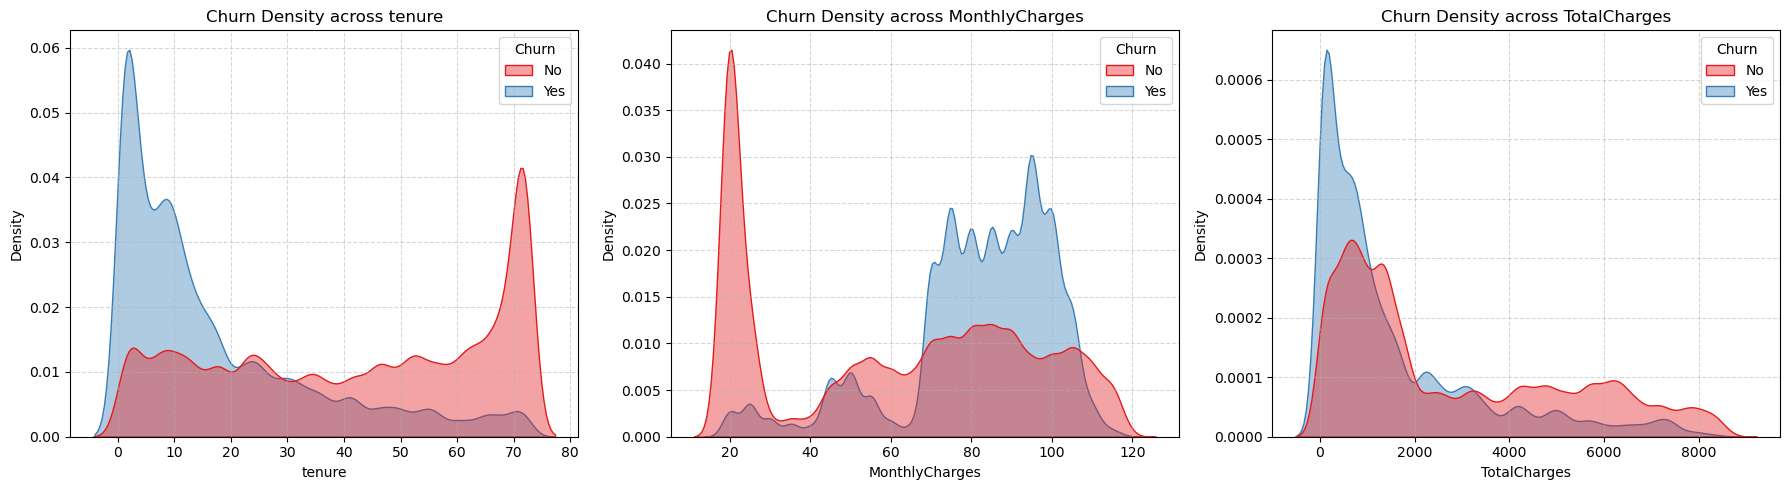

In [44]:
# Checking Density Plots for Numerical Features with respect to Churn
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_cols):
    sns.kdeplot(data=train_df, x=col, hue='Churn', fill=True, common_norm=False, 
                palette='Set1', alpha=0.4, ax=axes[i])
    axes[i].set_title(f'Churn Density across {col}')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

- **tenure:** High spikes from 0:15 months but then if its near 40:70 hardly any churn

- **Monthly Charges:** Lower charges tend to have less churn, but the relationship is not perfectly linear. Some customers with higher charges still stay.
- **Total Charges:** Most churn occurs in the `0–2000` range; once TotalCharges increases beyond that, churn drops noticeably, although there are still many non-churn cases within `0–2000`.

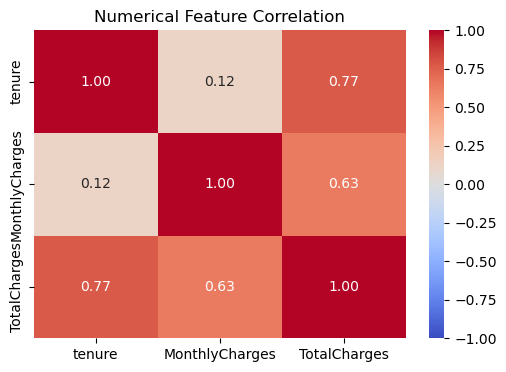

In [45]:
# Visualizing Correlation Heatmap for Numerical Features
plt.figure(figsize=(6, 4))
sns.heatmap(train[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Numerical Feature Correlation')
plt.show()


- **Tenure** and **Total Charges** are highly correlated.
- **Monthly Charges** and **Total Charges** are also strongly correlated.


# Data Cleaning

In [46]:
# Dropping the 'id' column from the training dataset as it is not needed for modeling
train_ids = train_df['id']
train_df.drop(columns=['id'], inplace=True)

In [47]:
# Mapping Churn values to binary (1 for Yes, 0 for No) for modeling purposes
train_df["Churn"] = train_df["Churn"].map({"Yes": 1, "No": 0})

In [48]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train_df[cat_cols] = encoder.fit_transform(train_df[cat_cols])
test_df[cat_cols] = encoder.transform(test_df[cat_cols])

# Model Creation and Improvement